# IMPORTING DEPENDENCIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_curve, 
                              auc, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ABOUT DATASET

In [2]:
df = pd.read_csv(r"dataset\global_student_digital_behavior_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   country                         500000 non-null  object 
 2   development_level               500000 non-null  object 
 3   poverty_rate_percent            500000 non-null  float64
 4   internet_infrastructure_index   500000 non-null  float64
 5   average_internet_speed_mbps     500000 non-null  float64
 6   age                             500000 non-null  int64  
 7   gender                          500000 non-null  object 
 8   urban_rural                     500000 non-null  object 
 9   family_income_level             500000 non-null  object 
 10  device_access                   500000 non-null  object 
 11  internet_access_hours           500000 non-null  float64
 12  education_level 

# DATASET CLEANING

In [3]:
df = df.drop(columns=['field_of_study'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   country                         500000 non-null  object 
 2   development_level               500000 non-null  object 
 3   poverty_rate_percent            500000 non-null  float64
 4   internet_infrastructure_index   500000 non-null  float64
 5   average_internet_speed_mbps     500000 non-null  float64
 6   age                             500000 non-null  int64  
 7   gender                          500000 non-null  object 
 8   urban_rural                     500000 non-null  object 
 9   family_income_level             500000 non-null  object 
 10  device_access                   500000 non-null  object 
 11  internet_access_hours           500000 non-null  float64
 12  education_level 

In [4]:
df['brain_rot_level'].unique()

array(['Low', 'Moderate', nan], dtype=object)

In [5]:
print(df.groupby('brain_rot_level')['brain_rot_index'].describe().round(2))

                    count   mean   std   min    25%    50%    75%   max
brain_rot_level                                                        
Low              432156.0  17.06  6.98   0.0  11.98  17.29  22.50  30.0
Moderate          61582.0  34.76  3.95  30.0  31.65  33.79  36.89  59.0


In [6]:
# Impute brain_rot_level based on brain_rot_index ranges
df['brain_rot_level'] = pd.cut(df['brain_rot_index'],
                                bins=[-float('inf'), 30, float('inf')],
                                labels=['Low', 'Moderate'])

# Verify
print(df['brain_rot_level'].value_counts())
print(df['brain_rot_level'].isnull().sum())

brain_rot_level
Low         438418
Moderate     61582
Name: count, dtype: int64
0


# DATA EXPLORATION

In [7]:
cols_needed = ['social_media_hours', 'sessions_per_day',
                'average_session_length_minutes', 'short_video_hours',
                'late_night_usage','digital_addiction_score', 'brain_rot_index',
                'attention_span_minutes', 'productivity_score',
                'age']


df_analysis = df[cols_needed].copy()
print(df_analysis.shape)
print(df_analysis.dtypes)

(500000, 10)
social_media_hours                float64
sessions_per_day                  float64
average_session_length_minutes    float64
short_video_hours                 float64
late_night_usage                   object
digital_addiction_score           float64
brain_rot_index                   float64
attention_span_minutes            float64
productivity_score                float64
age                                 int64
dtype: object


### Data Quality Check

In [27]:
# Missing values
print(df_analysis.isnull().sum())

# Duplicates
print(f"Duplicates: {df_analysis.duplicated().sum()}")


social_media_hours                0
sessions_per_day                  0
average_session_length_minutes    0
short_video_hours                 0
late_night_usage                  0
digital_addiction_score           0
brain_rot_index                   0
attention_span_minutes            0
productivity_score                0
age                               0
sm_group                          0
late_night_encoded                0
age_group                         0
attention_class                   0
prod_class                        0
dtype: int64
Duplicates: 0


### Distribution of Key Variables

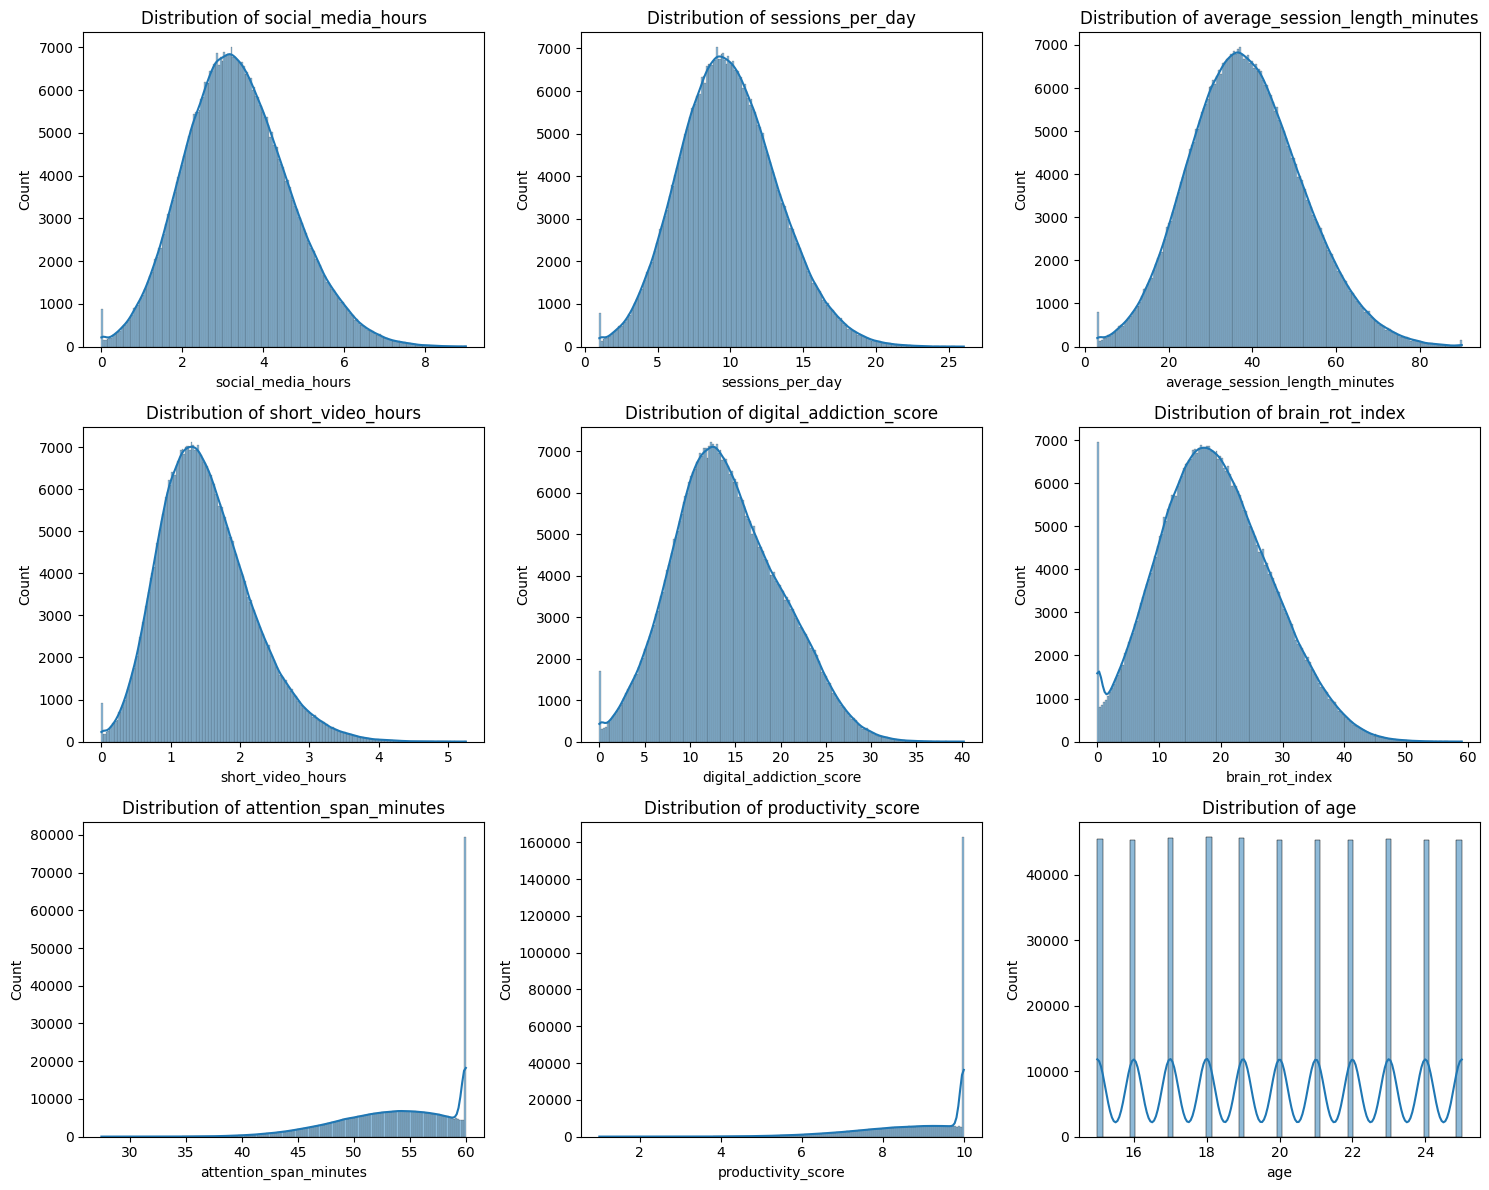

In [9]:
num_cols = ['social_media_hours', 'sessions_per_day',
            'average_session_length_minutes', 'short_video_hours',
            'digital_addiction_score', 'brain_rot_index',
            'attention_span_minutes', 'productivity_score', 'age']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(num_cols):
    sns.histplot(df_analysis[col], kde=True, ax=axes[i//3][i%3])
    axes[i//3][i%3].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Outlier Detection

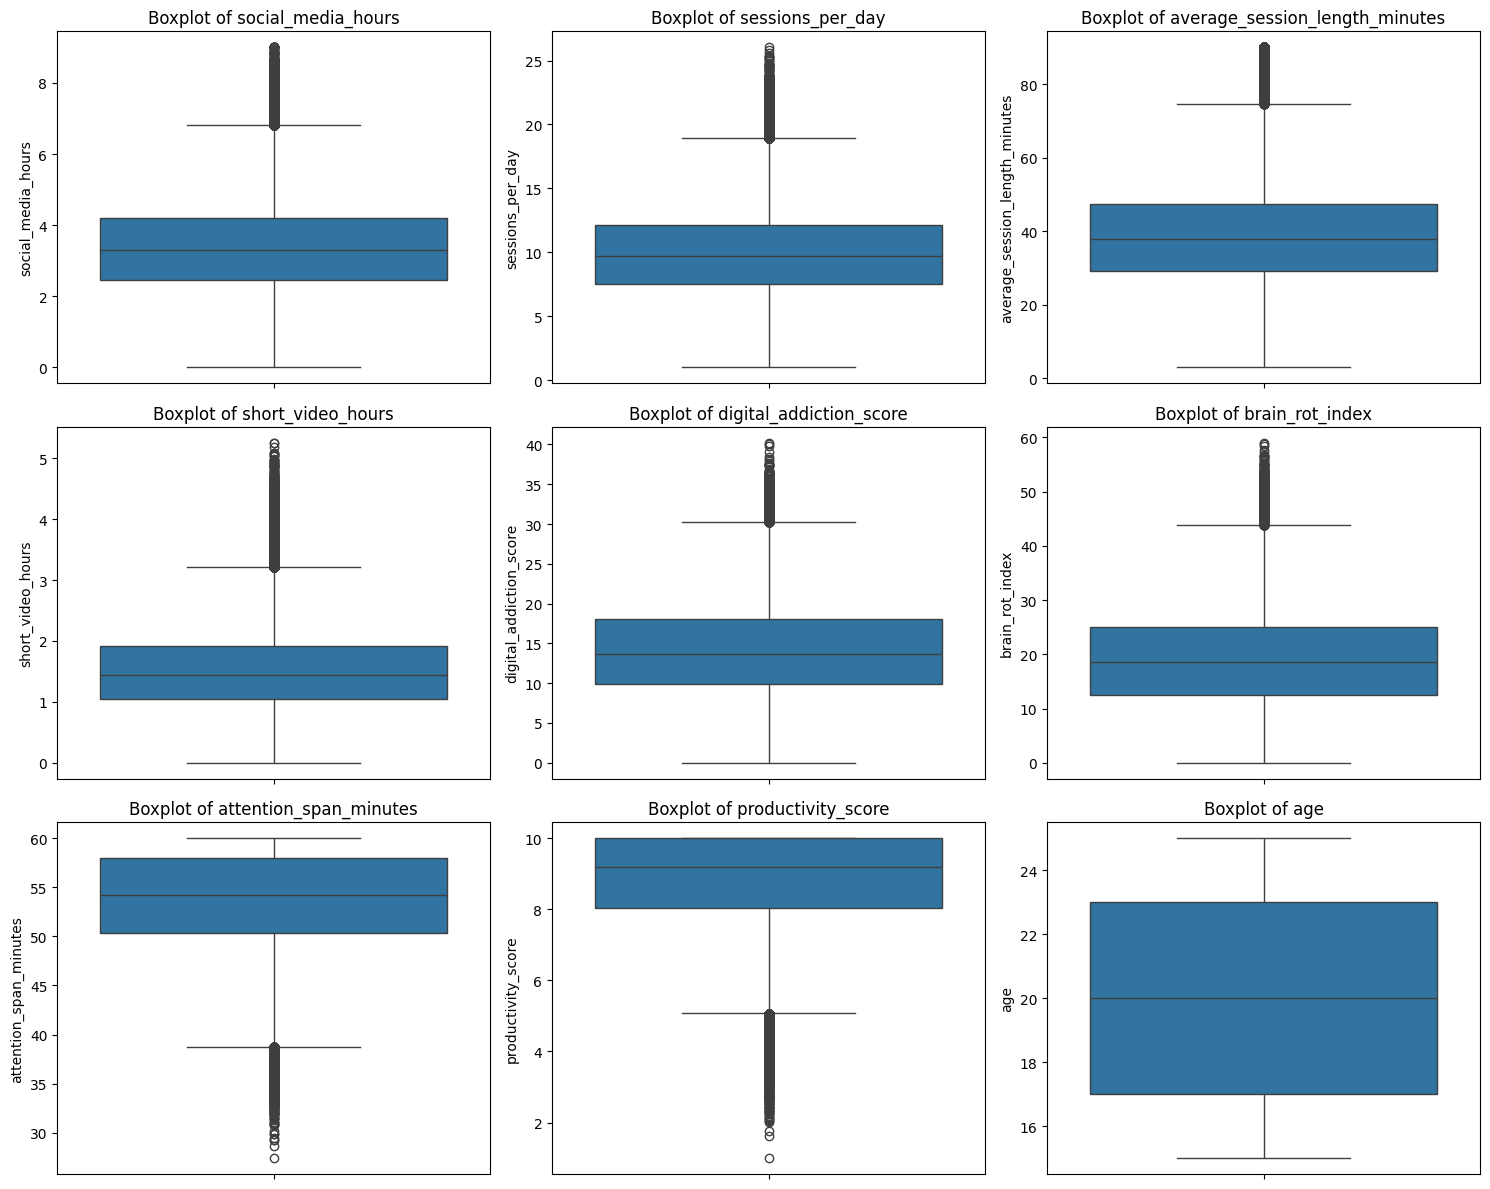

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_analysis[col], ax=axes[i//3][i%3])
    axes[i//3][i%3].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Correlation Heatmap

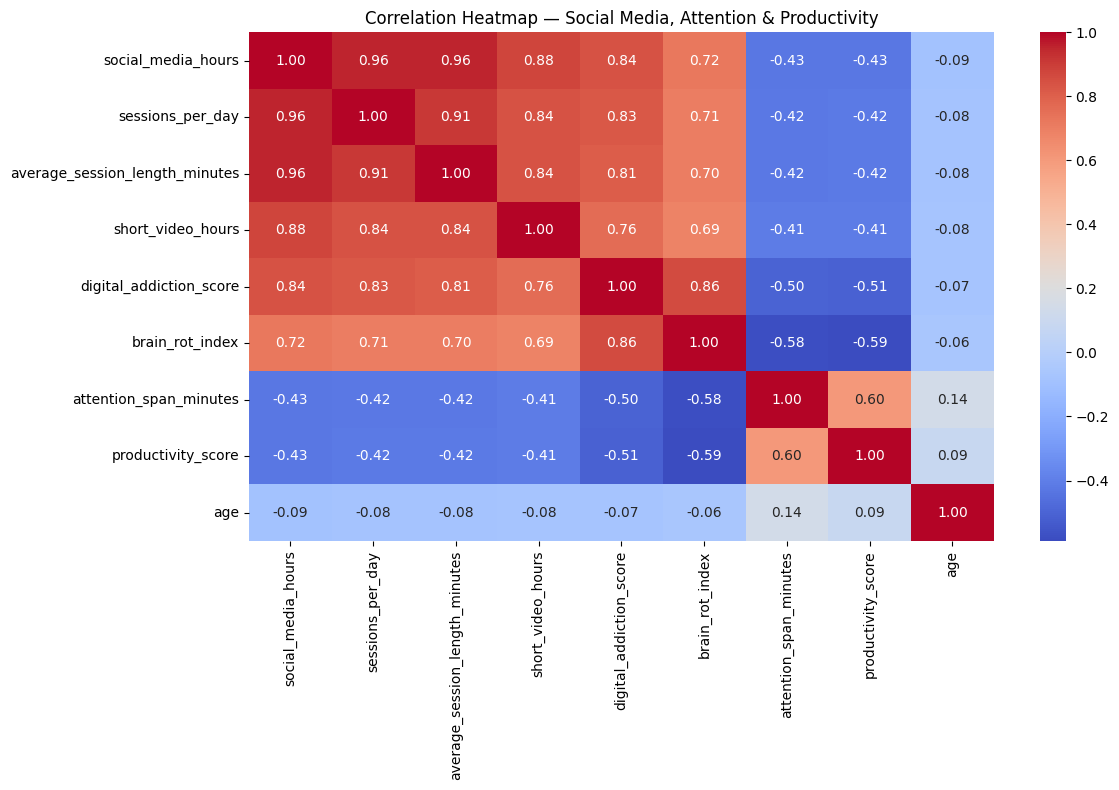

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_analysis[num_cols].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Social Media, Attention & Productivity')
plt.tight_layout()
plt.show()

### Data Transformation

In [12]:
# Bin social media hours into addiction groups
df_analysis['sm_group'] = pd.cut(df_analysis['social_media_hours'],
                                  bins=[-float('inf'), 2, 4, 6, float('inf')],
                                  labels=['Low', 'Moderate', 'High', 'Very High'])

# Encode late_night_usage
df_analysis['late_night_encoded'] = df_analysis['late_night_usage'].map(
    {'Never': 0, 'Sometimes': 1, 'Often': 2, 'Always': 3})

# Bin age into younger generation groups
df_analysis['age_group'] = pd.cut(df_analysis['age'],
                                   bins=[14, 17, 19, 22, 25],
                                   labels=['15-17', '18-19', '20-22', '23-25'])

# Verify all fixed
print(df_analysis['sm_group'].isnull().sum())
print(df_analysis['late_night_encoded'].isnull().sum())
print(df_analysis['age_group'].isnull().sum())

0
0
0


### EDA

In [13]:
# Social media group vs attention and productivity
print(df_analysis.groupby('sm_group', observed=True)[
    ['attention_span_minutes', 'productivity_score',
     'digital_addiction_score', 'brain_rot_index']].mean().round(2))

# Late night usage impact
print(df_analysis.groupby('late_night_usage')[
    ['attention_span_minutes', 'productivity_score']].mean().round(2))

# Age group patterns
print(df_analysis.groupby('age_group', observed=True)[
    ['social_media_hours', 'attention_span_minutes',
     'productivity_score']].mean().round(2))

           attention_span_minutes  productivity_score  \
sm_group                                                
Low                         56.54                9.50   
Moderate                    54.57                9.07   
High                        50.95                8.11   
Very High                   48.27                7.37   

           digital_addiction_score  brain_rot_index  
sm_group                                             
Low                           6.92             9.76  
Moderate                     12.40            16.68  
High                         20.15            27.28  
Very High                    25.61            33.98  
                  attention_span_minutes  productivity_score
late_night_usage                                            
Always                             48.63                7.41
Never                              56.31                9.47
Often                              51.79                8.33
Sometimes                   

# LINEAR REGRESSION

### Attention Span

##### After looking in below code we can see some cols have p-value more than 0.05 and hence multicollinearity.

In [14]:
features = ['social_media_hours', 'sessions_per_day',
            'average_session_length_minutes', 'short_video_hours',
            'digital_addiction_score', 'brain_rot_index',
            'late_night_encoded', 'age']

X = df_analysis[features]
y = df_analysis['attention_span_minutes']

X_const = sm.add_constant(X)
model_attention = sm.OLS(y, X_const).fit()
print(model_attention.summary())

                              OLS Regression Results                              
Dep. Variable:     attention_span_minutes   R-squared:                       0.345
Model:                                OLS   Adj. R-squared:                  0.345
Method:                     Least Squares   F-statistic:                 3.293e+04
Date:                    Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                            18:11:02   Log-Likelihood:            -1.4086e+06
No. Observations:                  500000   AIC:                         2.817e+06
Df Residuals:                      499991   BIC:                         2.817e+06
Df Model:                               8                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

##### After removing multicollinearity

In [15]:
features_clean = ['social_media_hours', 'short_video_hours',
                  'brain_rot_index', 'late_night_encoded', 'age']

X_clean = df_analysis[features_clean]
y = df_analysis['attention_span_minutes']

X_const_clean = sm.add_constant(X_clean)
model_attention_clean = sm.OLS(y, X_const_clean).fit()
print(model_attention_clean.summary())

                              OLS Regression Results                              
Dep. Variable:     attention_span_minutes   R-squared:                       0.345
Model:                                OLS   Adj. R-squared:                  0.345
Method:                     Least Squares   F-statistic:                 5.269e+04
Date:                    Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                            18:11:02   Log-Likelihood:            -1.4086e+06
No. Observations:                  500000   AIC:                         2.817e+06
Df Residuals:                      499994   BIC:                         2.817e+06
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### Productivity

In [16]:
features_clean = ['social_media_hours', 'short_video_hours',
                  'brain_rot_index', 'late_night_encoded', 'age']

X_clean = df_analysis[features_clean]
y_prod = df_analysis['productivity_score']

X_const_prod = sm.add_constant(X_clean)
model_prod = sm.OLS(y_prod, X_const_prod).fit()
print(model_prod.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                 5.366e+04
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        18:11:03   Log-Likelihood:            -7.2421e+05
No. Observations:              500000   AIC:                         1.448e+06
Df Residuals:                  499994   BIC:                         1.449e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.0021      0

# LOGISTIC REGRESSION

In [17]:
# High vs Low attention span (median split)
df_analysis['attention_class'] = (
    df_analysis['attention_span_minutes'] >= 
    df_analysis['attention_span_minutes'].median()).astype(int)

# High vs Low productivity (median split)
df_analysis['prod_class'] = (
    df_analysis['productivity_score'] >= 
    df_analysis['productivity_score'].median()).astype(int)

print(df_analysis['attention_class'].value_counts())
print(df_analysis['prod_class'].value_counts())
print(f"Attention median: {df_analysis['attention_span_minutes'].median()}")
print(f"Productivity median: {df_analysis['productivity_score'].median()}")

attention_class
1    250000
0    250000
Name: count, dtype: int64
prod_class
1    250000
0    250000
Name: count, dtype: int64
Attention median: 54.20835695311464
Productivity median: 9.189598539108033


### Attention Span

In [18]:
features_log = ['social_media_hours', 'short_video_hours',
                'brain_rot_index', 'late_night_encoded', 'age']

X = df_analysis[features_log]
y_att = df_analysis['attention_class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_att, test_size=0.2, random_state=42)

# Fit model
log_att = LogisticRegression(random_state=42, max_iter=1000)
log_att.fit(X_train, y_train)
y_pred_att = log_att.predict(X_test)
y_prob_att = log_att.predict_proba(X_test)[:, 1]

print("=== Attention Span Classifier ===")
print(classification_report(y_test, y_pred_att))

# ROC AUC
fpr_att, tpr_att, _ = roc_curve(y_test, y_prob_att)
auc_att = auc(fpr_att, tpr_att)
print(f"AUC Score: {auc_att:.3f}")

=== Attention Span Classifier ===
              precision    recall  f1-score   support

           0       0.72      0.69      0.70     50290
           1       0.70      0.73      0.71     49710

    accuracy                           0.71    100000
   macro avg       0.71      0.71      0.71    100000
weighted avg       0.71      0.71      0.71    100000

AUC Score: 0.782


### Productivity

In [19]:
y_prod = df_analysis['prod_class']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled, y_prod, test_size=0.2, random_state=42)

log_prod = LogisticRegression(random_state=42, max_iter=1000)
log_prod.fit(X_train2, y_train2)
y_pred_prod = log_prod.predict(X_test2)
y_prob_prod = log_prod.predict_proba(X_test2)[:, 1]

print("=== Productivity Classifier ===")
print(classification_report(y_test2, y_pred_prod))

# ROC AUC
fpr_prod, tpr_prod, _ = roc_curve(y_test2, y_prob_prod)
auc_prod = auc(fpr_prod, tpr_prod)
print(f"AUC Score: {auc_prod:.3f}")

=== Productivity Classifier ===
              precision    recall  f1-score   support

           0       0.72      0.70      0.71     50110
           1       0.71      0.73      0.72     49890

    accuracy                           0.71    100000
   macro avg       0.71      0.71      0.71    100000
weighted avg       0.71      0.71      0.71    100000

AUC Score: 0.790


### ROC Curve

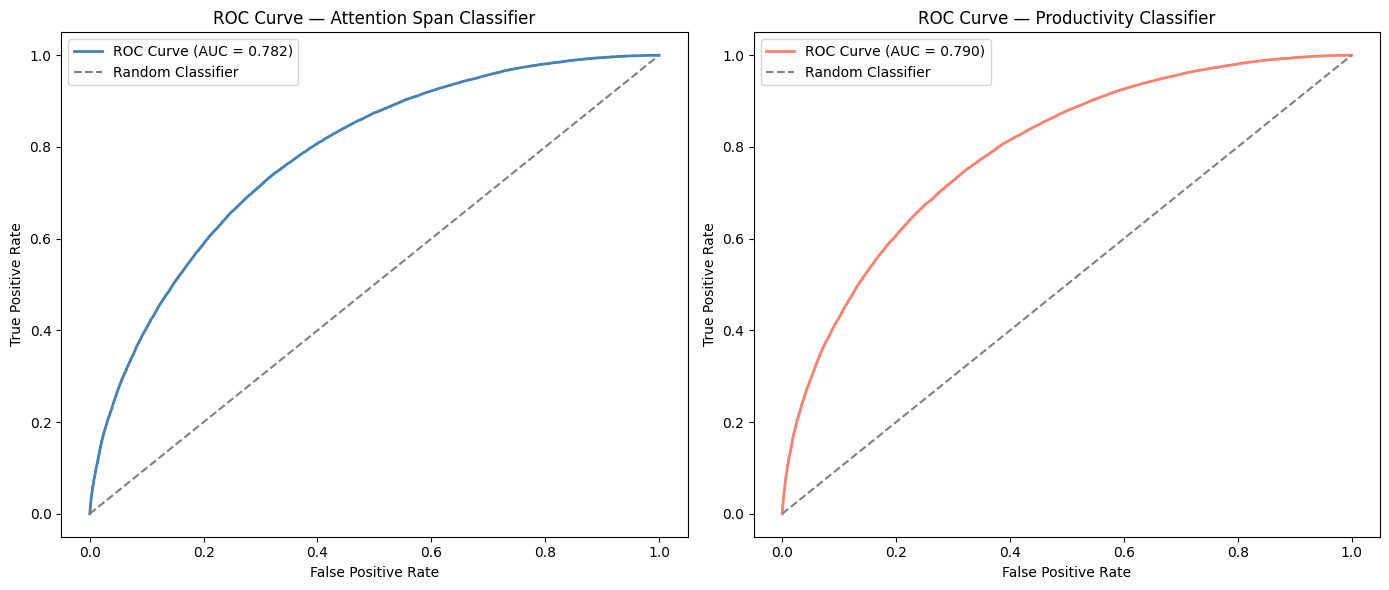

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Attention ROC
axes[0].plot(fpr_att, tpr_att, color='steelblue', linewidth=2,
             label=f'ROC Curve (AUC = {auc_att:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', 
             label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Attention Span Classifier')
axes[0].legend()

# Productivity ROC
axes[1].plot(fpr_prod, tpr_prod, color='salmon', linewidth=2,
             label=f'ROC Curve (AUC = {auc_prod:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Productivity Classifier')
axes[1].legend()

plt.tight_layout()
plt.show()

### Confusion Matrix

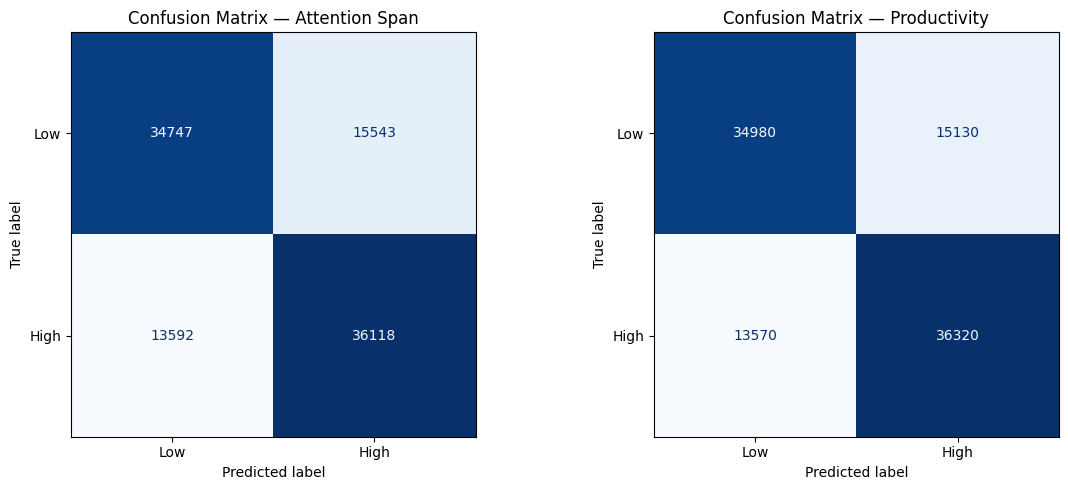

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Attention confusion matrix
cm_att = confusion_matrix(y_test, y_pred_att)
disp_att = ConfusionMatrixDisplay(confusion_matrix=cm_att,
                                   display_labels=['Low', 'High'])
disp_att.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Attention Span')

# Productivity confusion matrix
cm_prod = confusion_matrix(y_test2, y_pred_prod)
disp_prod = ConfusionMatrixDisplay(confusion_matrix=cm_prod,
                                    display_labels=['Low', 'High'])
disp_prod.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Productivity')

plt.tight_layout()
plt.show()

# STORYTELLING

#### Plot 1 — The Core Story: Social Media Group vs Attention & Productivity

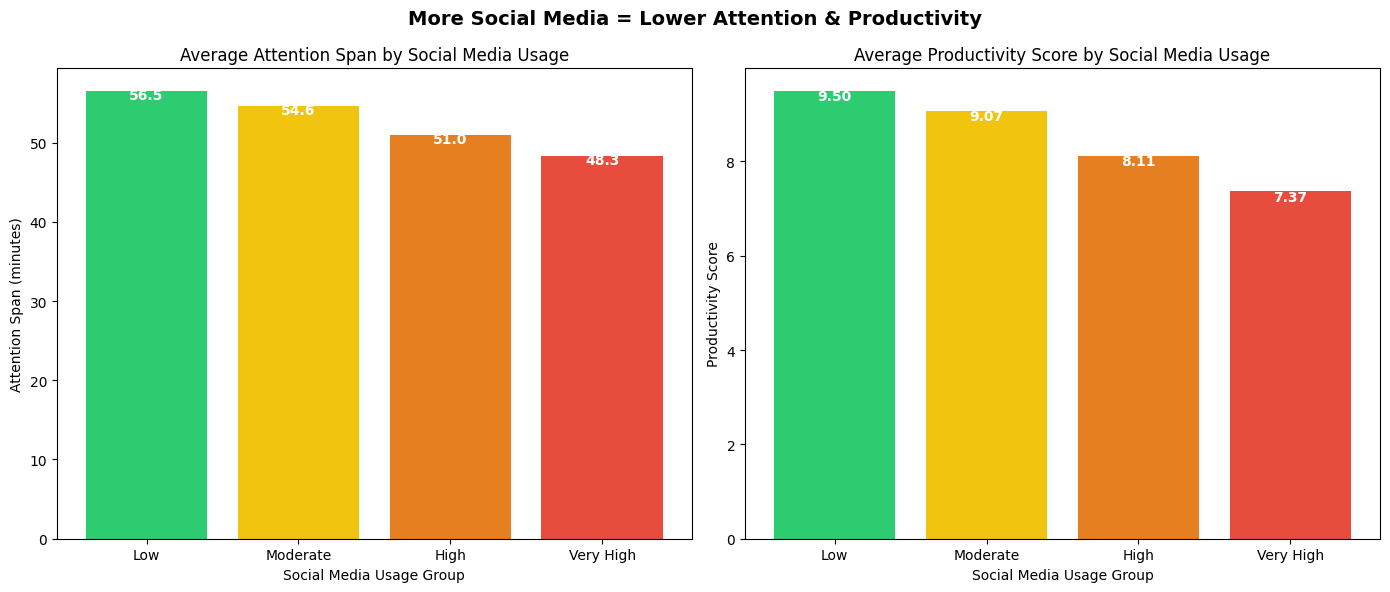

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = ['Low', 'Moderate', 'High', 'Very High']

# Attention span
group_data = df_analysis.groupby('sm_group', observed=True)[
    'attention_span_minutes'].mean().reindex(order)
axes[0].bar(order, group_data, color=['#2ecc71','#f1c40f','#e67e22',
                                      '#e74c3c'])
axes[0].set_title('Average Attention Span by Social Media Usage')
axes[0].set_xlabel('Social Media Usage Group')
axes[0].set_ylabel('Attention Span (minutes)')
for i, v in enumerate(group_data):
    axes[0].text(i, v-1, f'{v:.1f}', ha='center', 
                 fontweight='bold', color='white')

# Productivity
group_data2 = df_analysis.groupby('sm_group', observed=True)[
    'productivity_score'].mean().reindex(order)
axes[1].bar(order, group_data2, color=['#2ecc71','#f1c40f','#e67e22',
                                       '#e74c3c'])
axes[1].set_title('Average Productivity Score by Social Media Usage')
axes[1].set_xlabel('Social Media Usage Group')
axes[1].set_ylabel('Productivity Score')
for i, v in enumerate(group_data2):
    axes[1].text(i, v-0.2, f'{v:.2f}', ha='center',
                 fontweight='bold', color='white')

plt.suptitle('More Social Media = Lower Attention & Productivity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Plot 2 — The Mediator: Brain Rot Chain Reaction

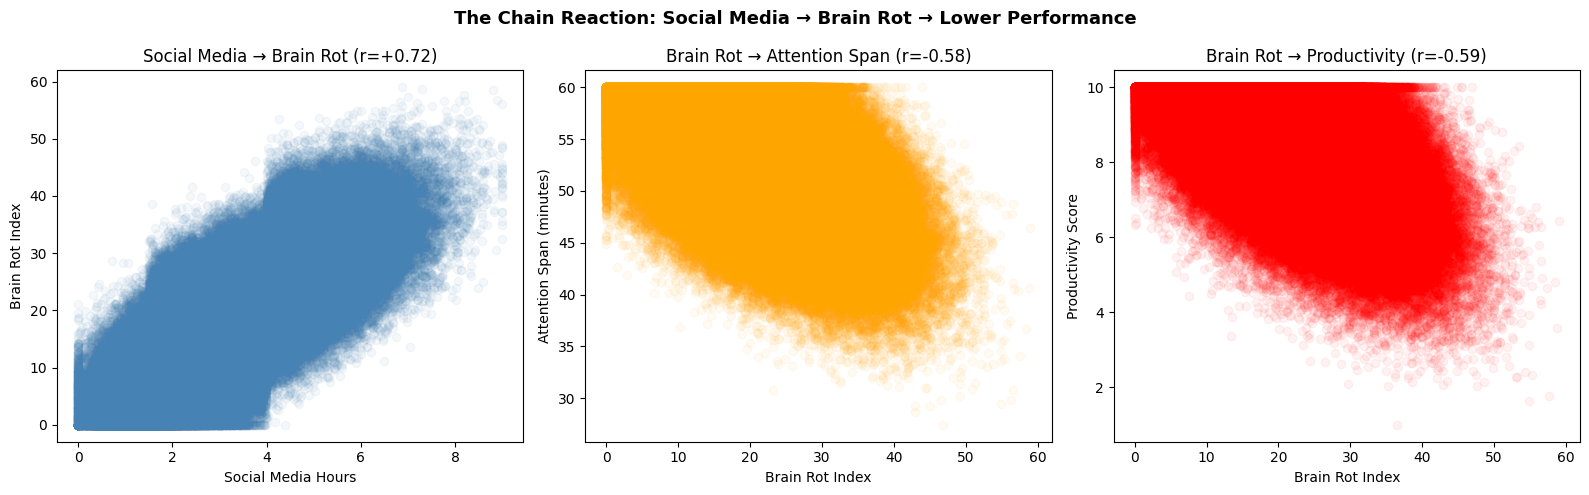

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Social media vs brain rot
axes[0].scatter(df_analysis['social_media_hours'],
                df_analysis['brain_rot_index'],
                alpha=0.05, color='steelblue')
axes[0].set_title('Social Media → Brain Rot (r=+0.72)')
axes[0].set_xlabel('Social Media Hours')
axes[0].set_ylabel('Brain Rot Index')

# Brain rot vs attention
axes[1].scatter(df_analysis['brain_rot_index'],
                df_analysis['attention_span_minutes'],
                alpha=0.05, color='orange')
axes[1].set_title('Brain Rot → Attention Span (r=-0.58)')
axes[1].set_xlabel('Brain Rot Index')
axes[1].set_ylabel('Attention Span (minutes)')

# Brain rot vs productivity
axes[2].scatter(df_analysis['brain_rot_index'],
                df_analysis['productivity_score'],
                alpha=0.05, color='red')
axes[2].set_title('Brain Rot → Productivity (r=-0.59)')
axes[2].set_xlabel('Brain Rot Index')
axes[2].set_ylabel('Productivity Score')

plt.suptitle('The Chain Reaction: Social Media → Brain Rot → Lower Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Plot 3 — Late Night Usage Impact

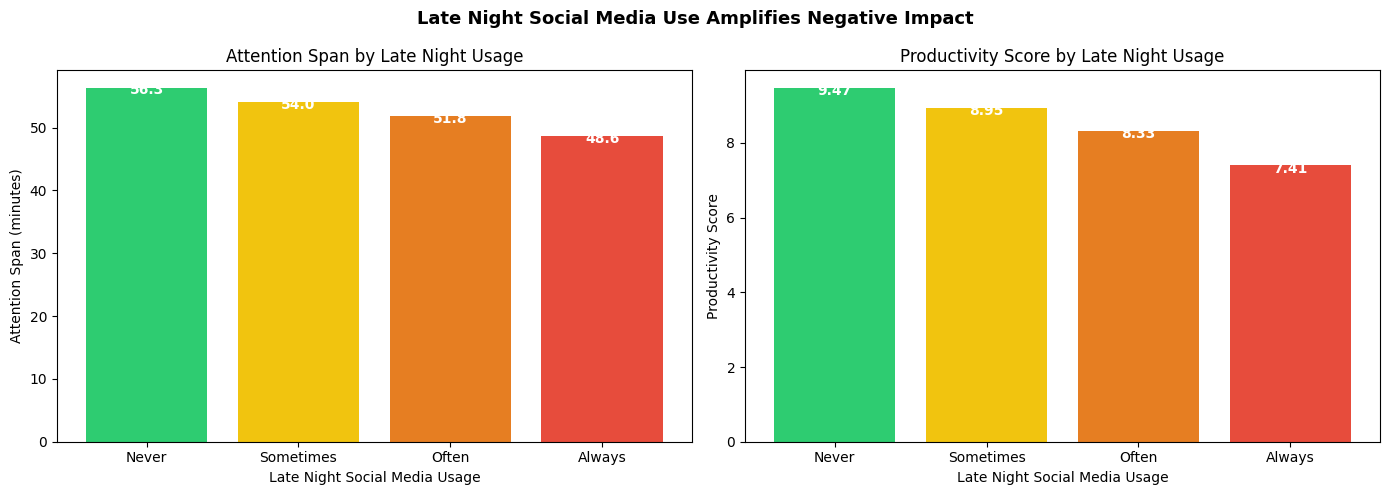

In [24]:
order_night = ['Never', 'Sometimes', 'Often', 'Always']
night_data = df_analysis.groupby('late_night_usage')[
    ['attention_span_minutes', 'productivity_score']].mean().reindex(order_night)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

axes[0].bar(order_night, night_data['attention_span_minutes'], color=colors)
axes[0].set_title('Attention Span by Late Night Usage')
axes[0].set_xlabel('Late Night Social Media Usage')
axes[0].set_ylabel('Attention Span (minutes)')
for i, v in enumerate(night_data['attention_span_minutes']):
    axes[0].text(i, v-1, f'{v:.1f}', ha='center',
                 fontweight='bold', color='white')

axes[1].bar(order_night, night_data['productivity_score'], color=colors)
axes[1].set_title('Productivity Score by Late Night Usage')
axes[1].set_xlabel('Late Night Social Media Usage')
axes[1].set_ylabel('Productivity Score')
for i, v in enumerate(night_data['productivity_score']):
    axes[1].text(i, v-0.2, f'{v:.2f}', ha='center',
                 fontweight='bold', color='white')

plt.suptitle('Late Night Social Media Use Amplifies Negative Impact',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Plot 4 — Age Group Patterns

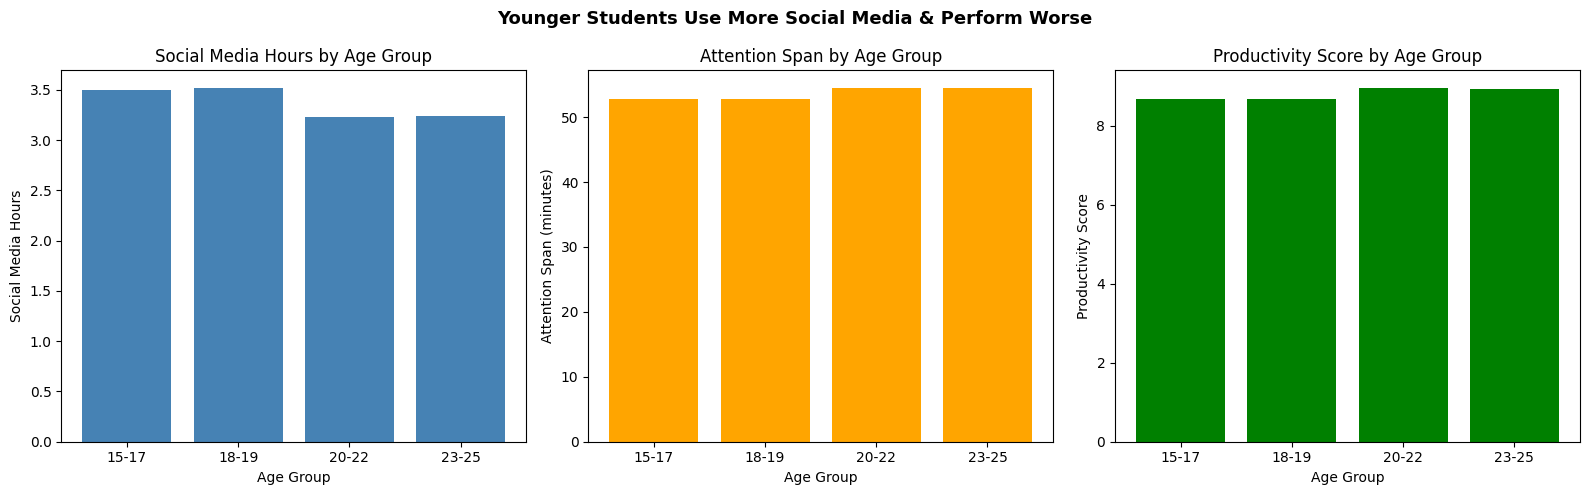

In [25]:
order_age = ['15-17', '18-19', '20-22', '23-25']
age_data = df_analysis.groupby('age_group', observed=True)[
    ['social_media_hours', 'attention_span_minutes',
     'productivity_score']].mean().reindex(order_age)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(order_age, age_data['social_media_hours'], color='steelblue')
axes[0].set_title('Social Media Hours by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Social Media Hours')

axes[1].bar(order_age, age_data['attention_span_minutes'], color='orange')
axes[1].set_title('Attention Span by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Attention Span (minutes)')

axes[2].bar(order_age, age_data['productivity_score'], color='green')
axes[2].set_title('Productivity Score by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Productivity Score')

plt.suptitle('Younger Students Use More Social Media & Perform Worse',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Plot 5 — Model Summary Visual

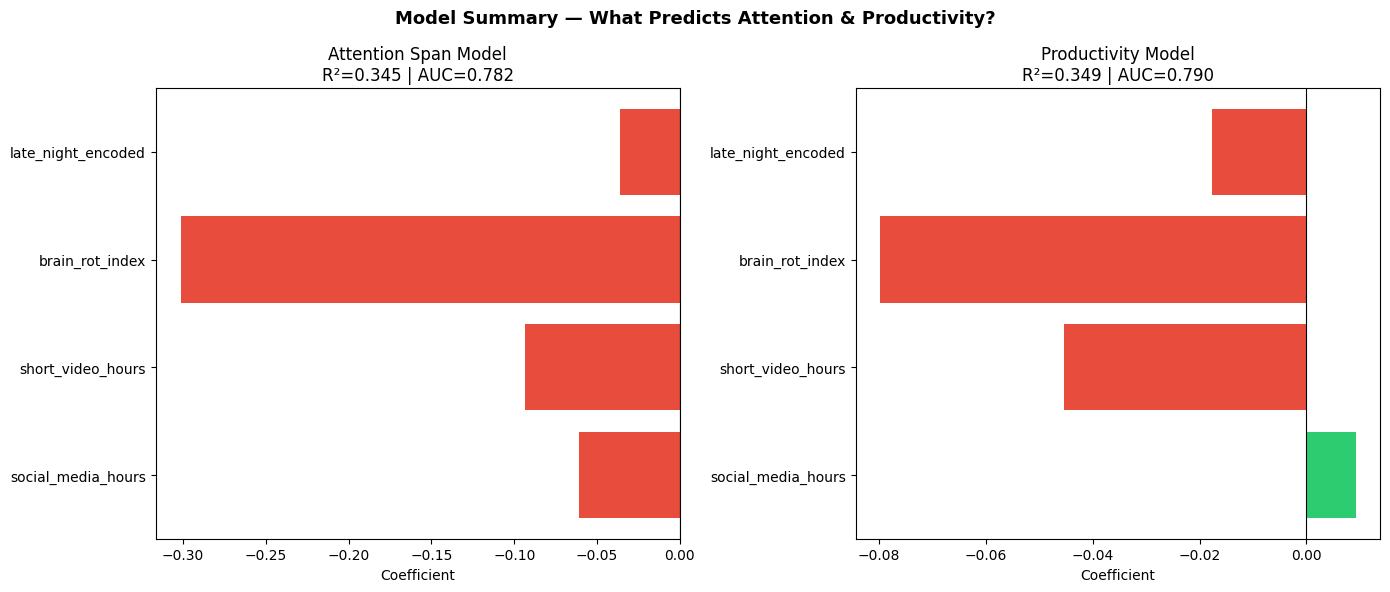

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Regression coefficients
features = ['social_media_hours', 'short_video_hours',
            'brain_rot_index', 'late_night_encoded']
att_coefs = [-0.0607, -0.0936, -0.3015, -0.0362]
prod_coefs = [0.0093, -0.0454, -0.0799, -0.0177]

colors_att = ['#e74c3c' if c < 0 else '#2ecc71' for c in att_coefs]
colors_prod = ['#e74c3c' if c < 0 else '#2ecc71' for c in prod_coefs]

axes[0].barh(features, att_coefs, color=colors_att)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title(f'Attention Span Model\nR²=0.345 | AUC=0.782')
axes[0].set_xlabel('Coefficient')

axes[1].barh(features, prod_coefs, color=colors_prod)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title(f'Productivity Model\nR²=0.349 | AUC=0.790')
axes[1].set_xlabel('Coefficient')

plt.suptitle('Model Summary — What Predicts Attention & Productivity?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# FEEDBACK

## STANDARDISED COEFFICIENTS

In [29]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
features_clean = ['social_media_hours', 'short_video_hours',
                  'brain_rot_index', 'late_night_encoded', 'age']

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_analysis[features_clean])
X_scaled_df = pd.DataFrame(X_scaled, columns=features_clean)

In [38]:
# Attention model
X_const_scaled = sm.add_constant(X_scaled_df)
model_att_std = sm.OLS(df_analysis['attention_span_minutes'], 
                        X_const_scaled).fit()
print("=== Standardised Attention Model ===")
print(model_att_std.summary())

=== Standardised Attention Model ===
                              OLS Regression Results                              
Dep. Variable:     attention_span_minutes   R-squared:                       0.345
Model:                                OLS   Adj. R-squared:                  0.345
Method:                     Least Squares   F-statistic:                 5.269e+04
Date:                    Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                            18:19:42   Log-Likelihood:            -1.4086e+06
No. Observations:                  500000   AIC:                         2.817e+06
Df Residuals:                      499994   BIC:                         2.817e+06
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

In [39]:
# Productivity model
model_prod_std = sm.OLS(df_analysis['productivity_score'],
                         X_const_scaled).fit()
print("=== Standardised Productivity Model ===")
print(model_prod_std.summary())

=== Standardised Productivity Model ===
                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                 5.366e+04
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        18:19:46   Log-Likelihood:            -7.2421e+05
No. Observations:              500000   AIC:                         1.448e+06
Df Residuals:                  499994   BIC:                         1.449e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

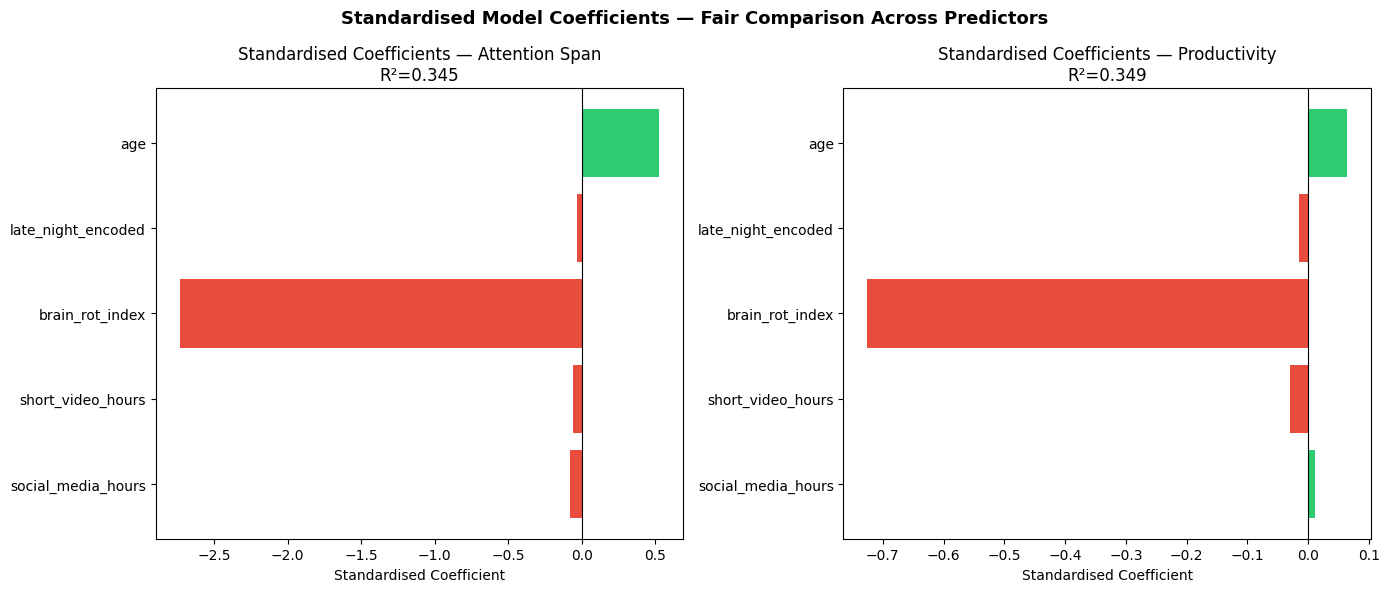

In [42]:
# Visualise standardised coefficients
att_std_coefs = model_att_std.params[features_clean].values
prod_std_coefs = model_prod_std.params[features_clean].values

coef_df = pd.DataFrame({
    'Feature': features_clean,
    'Attention': att_std_coefs,
    'Productivity': prod_std_coefs
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_att = ['#e74c3c' if c < 0 else '#2ecc71' for c in att_std_coefs]
colors_prod = ['#e74c3c' if c < 0 else '#2ecc71' for c in prod_std_coefs]

axes[0].barh(features_clean, att_std_coefs, color=colors_att)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Standardised Coefficients — Attention Span\nR²=0.345')
axes[0].set_xlabel('Standardised Coefficient')

axes[1].barh(features_clean, prod_std_coefs, color=colors_prod)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Standardised Coefficients — Productivity\nR²=0.349')
axes[1].set_xlabel('Standardised Coefficient')

plt.suptitle('Standardised Model Coefficients — Fair Comparison Across Predictors',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## MEDIATION ANALYSIS

In [43]:
# Install if needed
# !pip install pingouin

import pingouin as pg

# Mediation 1: social_media_hours → brain_rot_index → attention_span_minutes
print("=== Mediation Analysis: Social Media → Brain Rot → Attention ===")
med_attention = pg.mediation_analysis(
    data=df_analysis,
    x='social_media_hours',
    m='brain_rot_index',
    y='attention_span_minutes',
    n_boot=500,
    seed=42
)
print(med_attention)

# Mediation 2: social_media_hours → brain_rot_index → productivity_score
print("\n=== Mediation Analysis: Social Media → Brain Rot → Productivity ===")
med_productivity = pg.mediation_analysis(
    data=df_analysis,
    x='social_media_hours',
    m='brain_rot_index',
    y='productivity_score',
    n_boot=500,
    seed=42
)
print(med_productivity)

=== Mediation Analysis: Social Media → Brain Rot → Attention ===
                  path      coef        se          pval     CI2.5    CI97.5  \
0  brain_rot_index ~ X  5.065786  0.006869  0.000000e+00  5.052323  5.079248   
1  Y ~ brain_rot_index -0.318444  0.000637  0.000000e+00 -0.319692 -0.317196   
2                Total -1.676892  0.004932  0.000000e+00 -1.686558 -1.667226   
3               Direct -0.133048  0.006452  1.967581e-94 -0.145694 -0.120402   
4             Indirect -1.543845  0.004884  0.000000e+00 -1.553213 -1.534768   

   sig  
0  Yes  
1  Yes  
2  Yes  
3  Yes  
4  Yes  

=== Mediation Analysis: Social Media → Brain Rot → Productivity ===
                  path      coef        se          pval     CI2.5    CI97.5  \
0  brain_rot_index ~ X  5.065786  0.006869  0.000000e+00  5.052323  5.079248   
1  Y ~ brain_rot_index -0.082828  0.000161  0.000000e+00 -0.083143 -0.082512   
2                Total -0.425746  0.001260  0.000000e+00 -0.428215 -0.423276   
3          

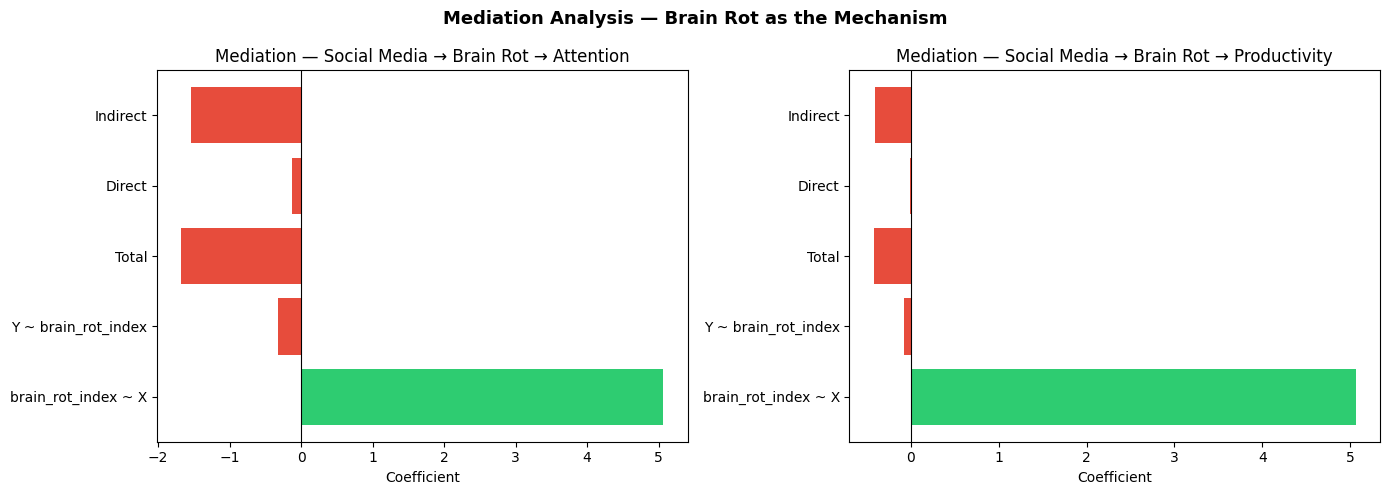

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attention mediation
effects_att = med_attention.set_index('path')['coef']
colors_med = ['#e74c3c' if v < 0 else '#2ecc71' 
              for v in effects_att.values]
axes[0].barh(effects_att.index, effects_att.values, color=colors_med)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Mediation — Social Media → Brain Rot → Attention')
axes[0].set_xlabel('Coefficient')

# Productivity mediation
effects_prod = med_productivity.set_index('path')['coef']
colors_med2 = ['#e74c3c' if v < 0 else '#2ecc71' 
               for v in effects_prod.values]
axes[1].barh(effects_prod.index, effects_prod.values, color=colors_med2)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Mediation — Social Media → Brain Rot → Productivity')
axes[1].set_xlabel('Coefficient')

plt.suptitle('Mediation Analysis — Brain Rot as the Mechanism',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## CROSS VALIDATION

In [45]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

In [46]:
features_clf = ['social_media_hours', 'short_video_hours',
                'brain_rot_index', 'late_night_encoded', 'age']

scaler = StandardScaler()
X_cv = scaler.fit_transform(df_analysis[features_clf])

# 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [48]:
# Attention class
y_att = df_analysis['attention_class']
scores_att = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_cv, y_att, cv=cv, scoring='roc_auc')

print("=== 5-Fold Cross Validation — Attention Span ===")
print(f"AUC per fold: {scores_att.round(3)}")
print(f"Mean AUC: {scores_att.mean():.3f} ± {scores_att.std():.3f}")

# Productivity class
y_prod = df_analysis['prod_class']
scores_prod = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_cv, y_prod, cv=cv, scoring='roc_auc')

print("\n=== 5-Fold Cross Validation — Productivity ===")
print(f"AUC per fold: {scores_prod.round(3)}")
print(f"Mean AUC: {scores_prod.mean():.3f} ± {scores_prod.std():.3f}")

=== 5-Fold Cross Validation — Attention Span ===
AUC per fold: [0.781 0.78  0.781 0.781 0.78 ]
Mean AUC: 0.780 ± 0.001

=== 5-Fold Cross Validation — Productivity ===
AUC per fold: [0.789 0.789 0.787 0.791 0.789]
Mean AUC: 0.789 ± 0.001


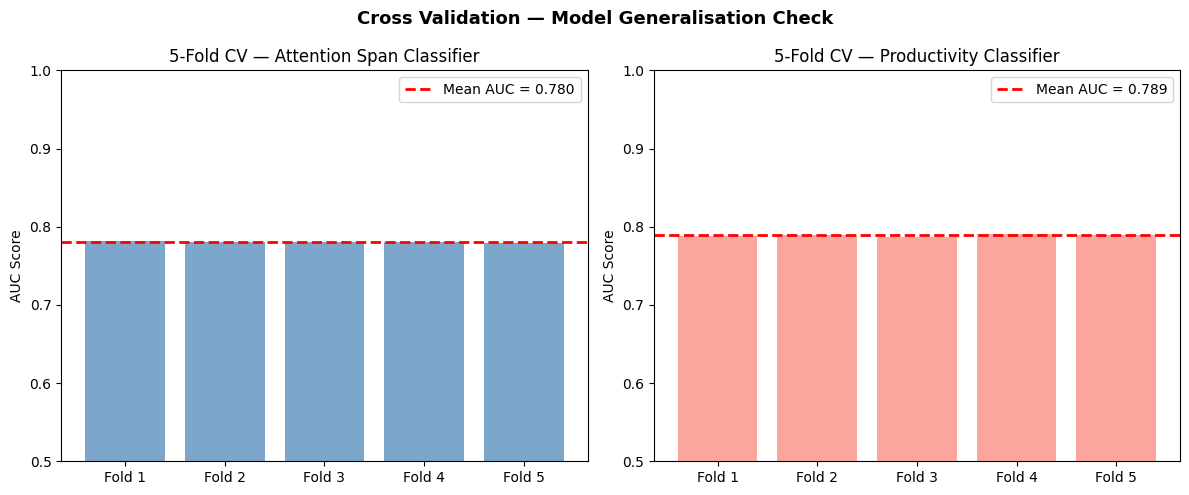

In [49]:
# Visualise cross validation results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

folds = [f'Fold {i+1}' for i in range(5)]

axes[0].bar(folds, scores_att, color='steelblue', alpha=0.7)
axes[0].axhline(y=scores_att.mean(), color='red', 
                linestyle='--', linewidth=2,
                label=f'Mean AUC = {scores_att.mean():.3f}')
axes[0].set_title('5-Fold CV — Attention Span Classifier')
axes[0].set_ylabel('AUC Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()

axes[1].bar(folds, scores_prod, color='salmon', alpha=0.7)
axes[1].axhline(y=scores_prod.mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean AUC = {scores_prod.mean():.3f}')
axes[1].set_title('5-Fold CV — Productivity Classifier')
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.suptitle('Cross Validation — Model Generalisation Check',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## RANDOM FOREST

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cv, y_att, test_size=0.2, random_state=42)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_cv, y_prod, test_size=0.2, random_state=42)


In [52]:
# Attention random forest
rf_att = RandomForestClassifier(n_estimators=100, 
                                 random_state=42, n_jobs=-1)
rf_att.fit(X_train, y_train)
y_prob_rf_att = rf_att.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_att)
auc_rf_att = auc(fpr_rf, tpr_rf)

print("=== Random Forest — Attention Span ===")
print(classification_report(y_test, rf_att.predict(X_test)))
print(f"AUC: {auc_rf_att:.3f}")

# Productivity random forest
rf_prod = RandomForestClassifier(n_estimators=100,
                                  random_state=42, n_jobs=-1)
rf_prod.fit(X_train2, y_train2)
y_prob_rf_prod = rf_prod.predict_proba(X_test2)[:, 1]
fpr_rf2, tpr_rf2, _ = roc_curve(y_test2, y_prob_rf_prod)
auc_rf_prod = auc(fpr_rf2, tpr_rf2)

print("\n=== Random Forest — Productivity ===")
print(classification_report(y_test2, rf_prod.predict(X_test2)))
print(f"AUC: {auc_rf_prod:.3f}")


=== Random Forest — Attention Span ===
              precision    recall  f1-score   support

           0       0.69      0.68      0.69     50290
           1       0.68      0.70      0.69     49710

    accuracy                           0.69    100000
   macro avg       0.69      0.69      0.69    100000
weighted avg       0.69      0.69      0.69    100000

AUC: 0.758

=== Random Forest — Productivity ===
              precision    recall  f1-score   support

           0       0.70      0.69      0.69     50110
           1       0.69      0.70      0.70     49890

    accuracy                           0.69    100000
   macro avg       0.69      0.69      0.69    100000
weighted avg       0.69      0.69      0.69    100000

AUC: 0.764


C:\Users\speeh\AppData\Local\Temp\ipykernel_29600\1624078551.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_att, x='Importance',
C:\Users\speeh\AppData\Local\Temp\ipykernel_29600\1624078551.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_prod, x='Importance',


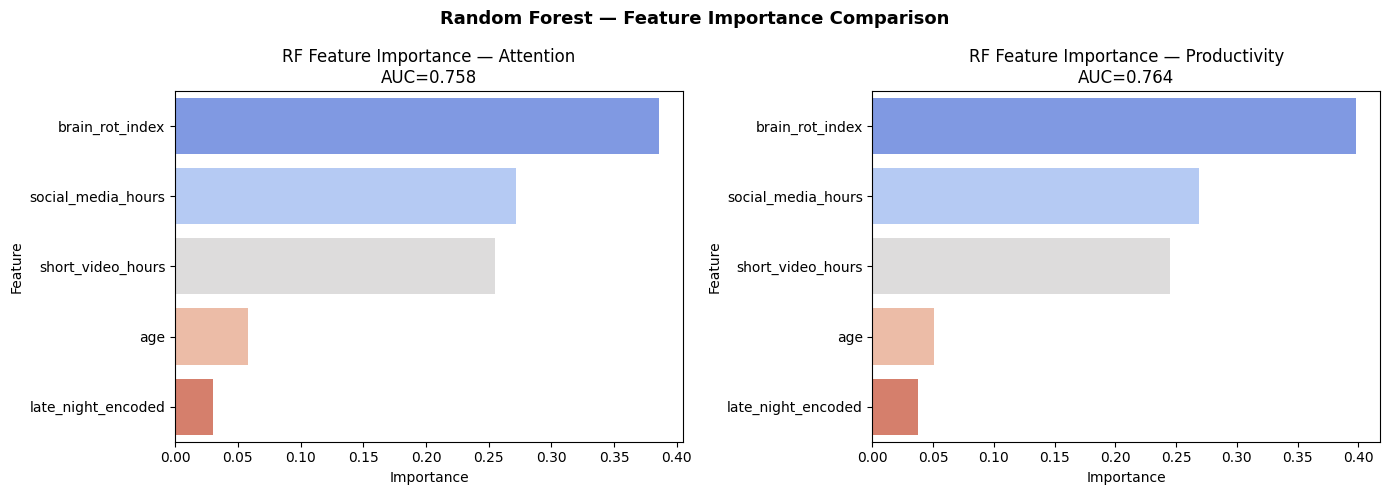

In [53]:
# Feature importance
feat_imp_att = pd.DataFrame({
    'Feature': features_clf,
    'Importance': rf_att.feature_importances_
}).sort_values('Importance', ascending=False)

feat_imp_prod = pd.DataFrame({
    'Feature': features_clf,
    'Importance': rf_prod.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=feat_imp_att, x='Importance', 
            y='Feature', palette='coolwarm', ax=axes[0])
axes[0].set_title(f'RF Feature Importance — Attention\nAUC={auc_rf_att:.3f}')

sns.barplot(data=feat_imp_prod, x='Importance',
            y='Feature', palette='coolwarm', ax=axes[1])
axes[1].set_title(f'RF Feature Importance — Productivity\nAUC={auc_rf_prod:.3f}')

plt.suptitle('Random Forest — Feature Importance Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### LOGISTIC REGRESSION VS RANDOM FOREST

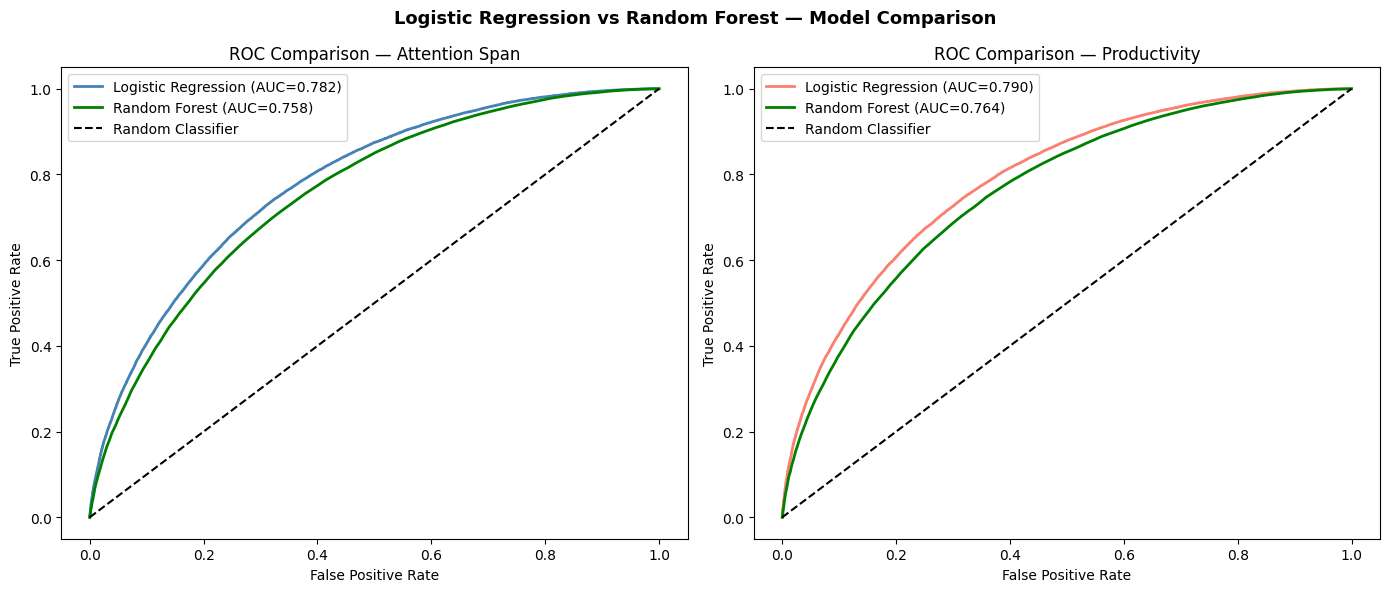

In [54]:
# Compare Logistic vs Random Forest ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Attention comparison
log_att_new = LogisticRegression(random_state=42, max_iter=1000)
log_att_new.fit(X_train, y_train)
y_prob_log_att = log_att_new.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log_att)
auc_log_att = auc(fpr_log, tpr_log)

axes[0].plot(fpr_log, tpr_log, color='steelblue', linewidth=2,
             label=f'Logistic Regression (AUC={auc_log_att:.3f})')
axes[0].plot(fpr_rf, tpr_rf, color='green', linewidth=2,
             label=f'Random Forest (AUC={auc_rf_att:.3f})')
axes[0].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Comparison — Attention Span')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Productivity comparison
log_prod_new = LogisticRegression(random_state=42, max_iter=1000)
log_prod_new.fit(X_train2, y_train2)
y_prob_log_prod = log_prod_new.predict_proba(X_test2)[:, 1]
fpr_log2, tpr_log2, _ = roc_curve(y_test2, y_prob_log_prod)
auc_log_prod = auc(fpr_log2, tpr_log2)

axes[1].plot(fpr_log2, tpr_log2, color='salmon', linewidth=2,
             label=f'Logistic Regression (AUC={auc_log_prod:.3f})')
axes[1].plot(fpr_rf2, tpr_rf2, color='green', linewidth=2,
             label=f'Random Forest (AUC={auc_rf_prod:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Comparison — Productivity')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.suptitle('Logistic Regression vs Random Forest — Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()